# Tutorial 16 — Silicon: thermoelectric transport (BoltzWann)

The waw-native reimagining of Wannier90 tutorial 16 (the postw90 **BoltzWann** module). Once we have a Wannier tight-binding model, the bands can be interpolated onto an arbitrarily dense mesh essentially for free — dense enough for **semiclassical Boltzmann transport** in the constant-relaxation-time approximation.

From the band velocities we build the **transport distribution function** $\Sigma_{ij}(E) = (\tau/V)\sum_{nk} v_i v_j\,\delta(E-\varepsilon_{nk})$, then the Mott integrals give the electrical conductivity $\sigma$, the **Seebeck coefficient** $S$, and the electronic thermal conductivity $\kappa$ as functions of chemical potential (doping) and temperature.

In [1]:
import os, sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

# locate the repo root (the folder containing the `waw` package), so the
# notebook runs from anywhere
HERE = pathlib.Path.cwd()
REPO = HERE
while not (REPO / 'waw').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import waw
from waw.interfaces import quantum_espresso as qe   # the direct-input QE driver
from waw.interfaces.ase.driver import wannierize
from waw.units import BOHR_TO_ANG, HARTREE_TO_EV
from waw.vis import plot_bands, BandSeries

PSEUDO_DIR = REPO / 'workflows' / 'pseudos'   # shared across workflows/, not w90tutorial-specific
NCORES = 16
waw.set_num_threads(NCORES)                  # use many cores for waw's batched linear algebra
print('waw', 'threads =', waw.get_num_threads(), '| repo', REPO)

waw threads = 16 | repo /aims_data/miguel/nas-data001/claude/wannier


### 1. Wannierise silicon
Same 8-MLWF disentanglement as tutorial 02 (the model just needs to be accurate across the valence bands and lower conduction).

In [2]:
from ase.build import bulk
from waw.interfaces.ase.structure import real_lattice, recip_lattice

atoms = bulk('Si', 'diamond', a=5.43)
MP_GRID = (4, 4, 4)
WORK = HERE / 'runs' / 'si'

ov = qe.generate_overlaps(
    atoms, MP_GRID, WORK, 'si',
    ecutwfc=40, scf_kpts=(8, 8, 8), nbnd=16, num_wann=8,
    scdm_entanglement='erfc', scdm_mu=12.0, scdm_sigma=4.0,
    pseudopotentials={'Si': 'Si.upf'}, pseudo_dir=PSEUDO_DIR, ncores=NCORES,
    rerun_scf=False,          # reuse a completed SCF in runs/si/ if present
)
result = wannierize(
    atoms, MP_GRID, ov['kpts'],
    mmn=ov['mmn'], amn=ov['amn'], eig=ov['eig'],
    nnkpts=ov['nnkpts'], g_vectors=ov['g_vectors'], nw=8,
    outer_window=(-1e3, 17.0), frozen_window=(-1e3, 6.4),
    n_restarts=3, dis_n_iter=1000, n_iter=6000, verbose=False,
)
REAL, RECIP = real_lattice(atoms), recip_lattice(atoms)
print(f'Omega_I = {result.dis.omega_i*BOHR_TO_ANG**2:.4f} Ang^2')

Omega_I = 11.9087 Ang^2


### Interpolated bands against the ab-initio reference
The Wannier bands (lines) over a non-self-consistent `calculation='bands'` run
along the same path (points), with the disentanglement windows shaded and
everything referred to $E_F$. Inside the frozen window the interpolation must
reproduce the ab-initio bands exactly; the printed deviation on the
Wannierization mesh itself is the quantitative form of the same statement.

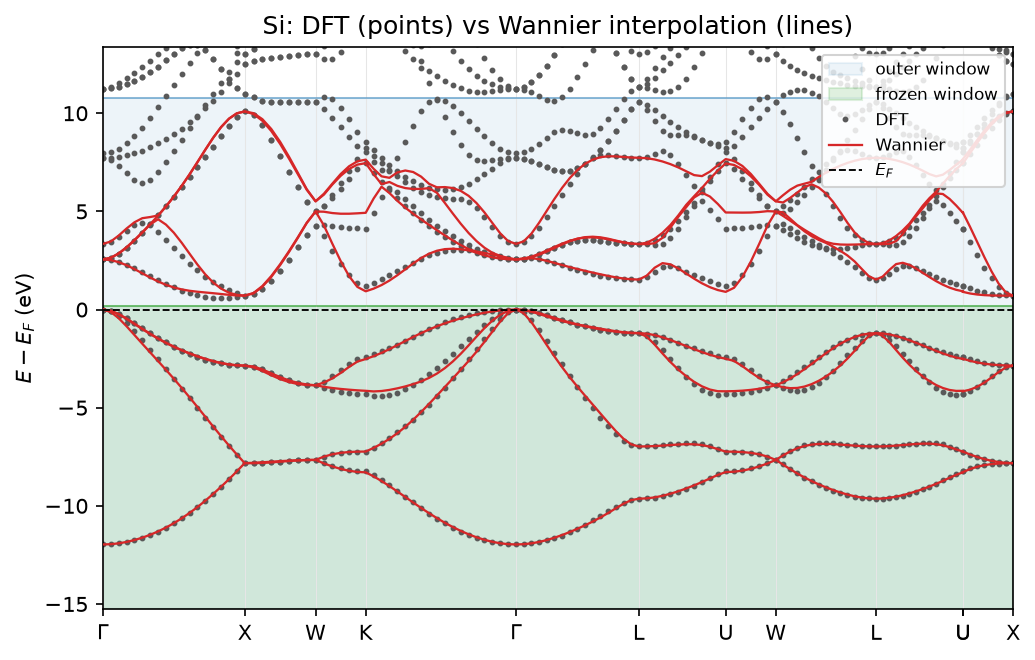

on the Wannier mesh, inside the frozen window: max 0.000 meV, rms 0.000 meV over 256 states


In [3]:
from waw.interfaces.ase.structure import band_path
from waw.core.hamiltonian import interpolate_bands
from waw.interfaces.quantum_espresso import bands_along_path
from waw.analysis.bands import mesh_fidelity
from waw.vis import plot_wannierization_windows

E_F = ov['fermi_energy']
bp = band_path(atoms, npoints=120)
xcoords, xspecial, labels = bp.get_linear_kpoint_axis()
bands = interpolate_bands(result.hr, bp.kpts) * HARTREE_TO_EV
try:
    dft_bands = bands_along_path(WORK, 'si', bp.kpts, ncores=NCORES)
except FileNotFoundError as exc:      # charge density not kept in this run dir
    dft_bands = np.full_like(bands, np.nan)
    print(exc)

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)
plot_wannierization_windows(
    ax, xcoords, dft_bands, bands,
    outer_window=(-1e3, 17.0), frozen_window=(-1e3, 6.4), fermi_energy=E_F,
    xticks=xspecial, xticklabels=[l.replace('G', r'$\Gamma$') for l in labels])
ax.set_title('Si: DFT (points) vs Wannier interpolation (lines)')
plt.tight_layout(); plt.show()

fid = mesh_fidelity(result.hr, ov['kpts'], ov['eig'],
                    window=(-1e3, 6.4), fermi_ev=E_F)
print(f"on the Wannier mesh, inside the frozen window: max {fid['max']:.3f} meV, "
      f"rms {fid['rms']:.3f} meV over {fid['n_states']} states")


### 2. Transport distribution function on a dense mesh
The TDF is interpolated on a **40×40×40** mesh (64 000 k-points — cheap band interpolation, and the band velocities are evaluated with the batched multi-core path). A constant relaxation time $\tau = 10$ fs sets the overall scale (the CRTA).

In [4]:
from waw.analysis import transport_distribution_function, transport_coefficients
from waw.units import EV_TO_HARTREE, K_B_HARTREE, to_si_units

TDF_MESH = (40, 40, 40)
TAU_FS = 10.0
tau_au = TAU_FS / 2.4188843265857e-2       # fs -> atomic time units

energies_eV = np.arange(-6.0, 15.0, 0.01)  # covers valence + lower conduction
tdf = transport_distribution_function(
    result.hr, REAL, RECIP, TDF_MESH,
    energies_eV * EV_TO_HARTREE, tau_au, num_elec_per_state=2,
)
print('TDF computed on', TDF_MESH, '=', np.prod(TDF_MESH), 'k-points')

TDF computed on (40, 40, 40) = 64000 k-points


### 3. Seebeck coefficient and conductivity vs doping
Sweeping the chemical potential $\mu$ across the gap turns silicon from **p-type** (below the valence-band maximum) to **n-type** (above the conduction-band minimum). The Seebeck coefficient changes sign accordingly and is largest just inside the gap; the conductivity grows as $\mu$ enters a band.

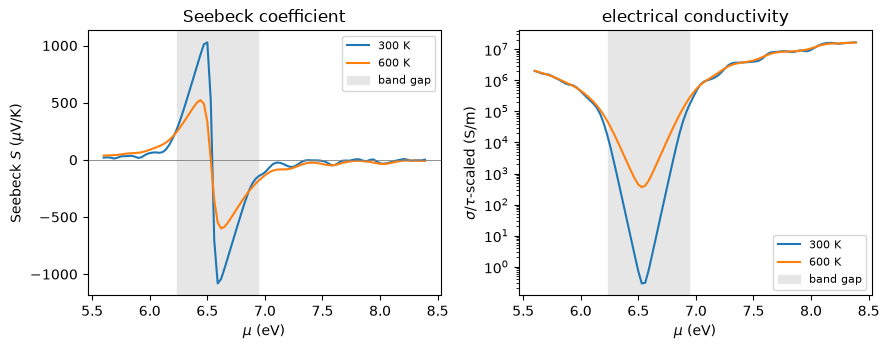

max |S| at 300 K: 1081 uV/K (sign flips p-type <-> n-type across the gap)


In [5]:
mu_eV = np.arange(5.6, 8.4, 0.03)
temps = np.array([300.0, 600.0])
kT = temps * K_B_HARTREE
bt = transport_coefficients(tdf, mu_eV * EV_TO_HARTREE, kT)
seebeck_si = to_si_units(bt.seebeck_reduced, 'seebeck')
elcond_si = to_si_units(bt.elcond, 'electrical_conductivity')

seebeck = seebeck_si[:, :, 0, 0] * 1e6      # V/K -> uV/K, (n_mu, n_T)
elcond = elcond_si[:, :, 0, 0]              # S/m, (n_mu, n_T)

fig, axs = plt.subplots(1, 2, figsize=(9, 3.6), sharex=True)
for it, T in enumerate(temps):
    axs[0].plot(mu_eV, seebeck[:, it], label=f'{T:.0f} K')
    axs[1].semilogy(mu_eV, elcond[:, it], label=f'{T:.0f} K')
for ax in axs:
    ax.axvspan(6.24, 6.94, color='0.9', label='band gap')
    ax.set_xlabel(r'$\mu$ (eV)'); ax.legend(fontsize=8)
axs[0].axhline(0.0, color='0.5', lw=0.6)
axs[0].set_ylabel(r'Seebeck $S$ ($\mu$V/K)'); axs[0].set_title('Seebeck coefficient')
axs[1].set_ylabel(r'$\sigma/\tau$-scaled (S/m)'); axs[1].set_title('electrical conductivity')
plt.tight_layout(); plt.show()
print('max |S| at 300 K:', f'{np.abs(seebeck[:,0]).max():.0f} uV/K',
      '(sign flips p-type <-> n-type across the gap)')

**Takeaway.** The Wannier model turns a coarse 4×4×4 DFT calculation into a dense-mesh transport calculation: the constant-relaxation-time Seebeck coefficient and conductivity of silicon vs doping and temperature — the postw90 BoltzWann workflow, waw-native and multi-core.